# **EDA**

### **Import Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeon.datasets import load_classification
print("AEON OK")

AEON OK


### **Load Dataset**

In [3]:
X_train, y_train = load_classification(
    name="DucksAndGeese",
    split="train",
    extract_path="../data",
    load_equal_length=False
)

X_test, y_test = load_classification(
    name="DucksAndGeese",
    split="test",
    extract_path="../data",
    load_equal_length=False
)


### **Verifikasi Struktur Data**

In [4]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("Tipe X_train :", type(X_train))
print("Tipe satu sample :", type(X_train[0]))
print("Shape satu sample :", X_train[0].shape)

Train shape: (50, 1, 236784)
Test shape : (50, 1, 236784)
Tipe X_train : <class 'numpy.ndarray'>
Tipe satu sample : <class 'numpy.ndarray'>
Shape satu sample : (1, 236784)


### **Distribusi Label**

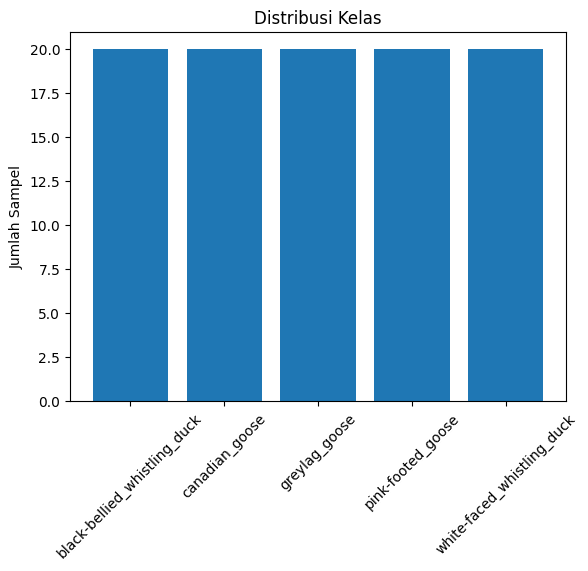

In [5]:
labels, counts = np.unique(
    np.concatenate([y_train, y_test]),
    return_counts=True
)

plt.bar(labels, counts)
plt.title("Distribusi Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45)
plt.show()


### **Visualisasi Waveform (per kelas)**

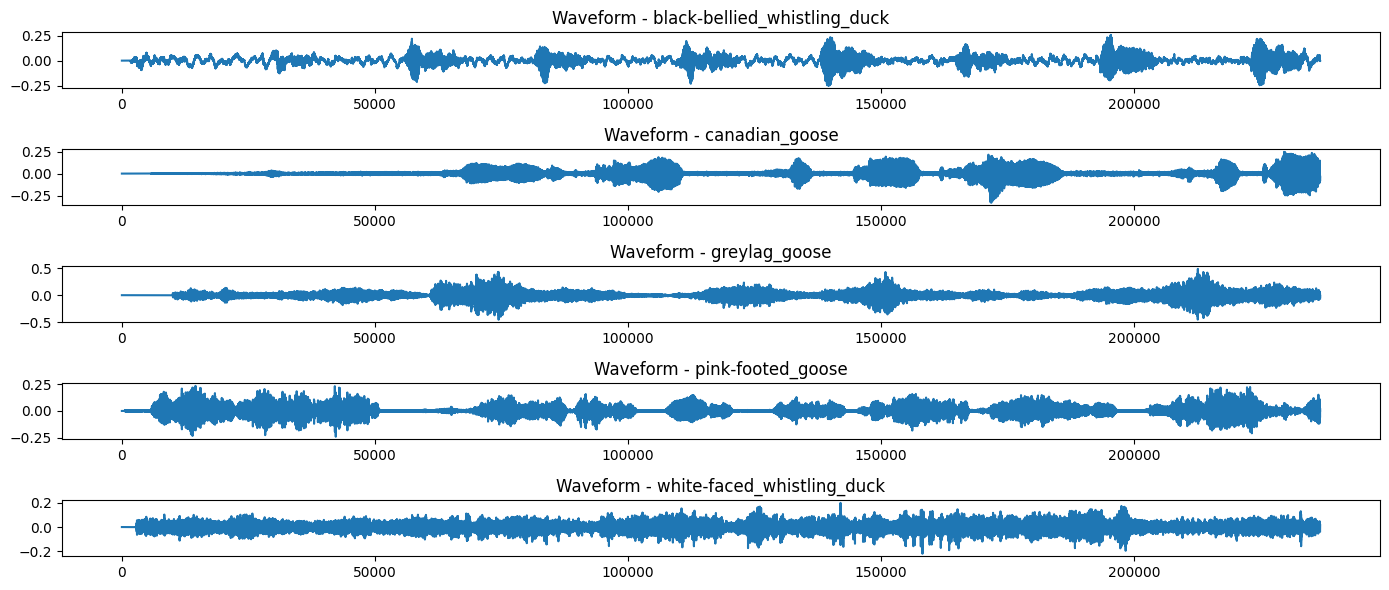

In [6]:
plt.figure(figsize=(14,6))

for i, label in enumerate(np.unique(y_train)):
    idx = np.where(y_train == label)[0][0]
    plt.subplot(5,1,i+1)
    plt.plot(X_train[idx][0])
    plt.title(f"Waveform - {label}")

plt.tight_layout()
plt.show()

### **Statistik Dasar Time Series**

In [7]:
def zero_crossing_rate(x):
    return np.mean(np.diff(np.sign(x)) != 0)

stats = []

for label in np.unique(y_train):
    idxs = np.where(y_train == label)[0]
    signals = [X_train[i][0] for i in idxs]

    stats.append({
        "Class": label,
        "Mean": np.mean([np.mean(s) for s in signals]),
        "Std": np.mean([np.std(s) for s in signals]),
        "RMS": np.mean([np.sqrt(np.mean(s**2)) for s in signals]),
        "ZCR": np.mean([zero_crossing_rate(s) for s in signals])
    })

df_stats = pd.DataFrame(stats)
df_stats


,Class,Mean,Std,RMS,ZCR
0,black-bellied_whistling_duck,-0.000021,0.060277,0.060277,0.153593
1,canadian_goose,-0.000039,0.034151,0.034153,0.121496
2,greylag_goose,-0.000534,0.041971,0.041997,0.106937
3,pink-footed_goose,-0.000046,0.050979,0.050979,0.099077
4,white-faced_whistling_duck,-0.000004,0.046251,0.046251,0.200909


### **Noise & Outlier Inspection**

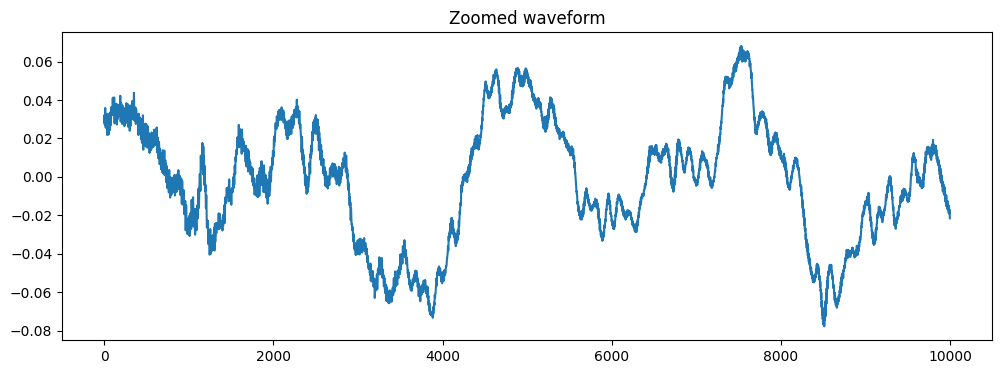

In [8]:
plt.figure(figsize=(12,4))
plt.plot(X_train[0][0][10000:20000])
plt.title("Zoomed waveform")
plt.show()

### **Penjelasan**

Berdasarkan EDA, dataset memiliki kelas seimbang, panjang sinyal yang seragam, namun variasi amplitudo dan pola temporal yang tinggi antar kelas. Hal ini menunjukkan bahwa metode berbasis pola temporal seperti CNN dan DTW relevan, serta diperlukan preprocessing berupa normalisasi dan ekstraksi fitur untuk mengurangi kompleksitas data.